# Data Exploration and Preparation

## Dataset 4: covid-qa-master

[Dataset4](https://github.com/deepset-ai/COVID-QA/tree/master/data)

### Data Description

#### **Dataset Origin and Context**

The COVID-QA dataset is an open-source Question Answering corpus released by deepset.ai in early 2020 during the COVID-19 pandemic. The dataset was created to support the development and evaluation of trustworthy, fact-based question answering systems by aggregating information from authoritative biomedical sources such as WHO, CDC, and peer-reviewed research articles
COVID-QA.

The dataset was originally designed in a SQuAD-style extractive QA format, where each question is paired with one or more answer spans extracted directly from scientific documents. This design ensures that answers are grounded in verifiable evidence, making the dataset especially suitable for healthcare and public health QA systems.

#### **Dataset Structure**

The dataset is provided as a JSON file (COVID-QA.json) with the following hierarchical structure:

- data (list)
  - paragraphs (list)
    - context: Long-form biomedical or public health text (often from research papers)
    - qas (list)
        - question: Natural language question
        - id: Unique question identifier
        - answers:
          - text: Ground-truth answer span
          - answer_start: Character index in context
        - is_impossible: Boolean flag (SQuAD 2.0 style)

Each context passage often spans hundreds to thousands of tokens, with multiple questions mapped to the same document.

#### **Appropriateness for This Study**

This dataset is highly aligned with your research objectives:

Research Requirement: Dataset Support
- Healthcare domain grounding: Peer-reviewed biomedical texts
- RAG-based QA: Context-heavy, retrieval-dependent
- Hallucination reduction:	Extractive, evidence-backed answers
- Citation-based responses:	Answer spans traceable to source
- Evaluation benchmark:	Gold-standard QA pairs

### Statistical & Exploratory Analysis

In [1]:
# Import Required Libraries

import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from typing import List, Dict

In [2]:
# Load JSON file
with open("/content/drive/MyDrive/MS-LJMU/Data/covid-qa-master/data/question-answering/COVID-QA.json", "r") as f:
    data = json.load(f)["data"]

records = []

for entry in data:
    for para in entry["paragraphs"]:
        context = para["context"]
        doc_id = para.get("document_id", None)
        for qa in para["qas"]:
            question = qa["question"]
            is_impossible = qa["is_impossible"]
            answers = qa["answers"]
            answer_text = answers[0]["text"] if answers else None

            records.append({
                "document_id": doc_id,
                "context": context,
                "question": question,
                "answer": answer_text,
                "is_impossible": is_impossible
            })

df4 = pd.DataFrame(records)
df4.head()

,document_id,context,question,answer,is_impossible
0,630,Functional Genetic Variants in DC-SIGNR Are As...,What is the main cause of HIV-1 infection in c...,Mother-to-child transmission (MTCT) is the mai...,False
1,630,Functional Genetic Variants in DC-SIGNR Are As...,What plays the crucial role in the Mother to C...,DC-SIGNR plays a crucial role in MTCT of HIV-1...,False
2,630,Functional Genetic Variants in DC-SIGNR Are As...,How many children were infected by HIV-1 in 20...,"more than 400,000 children were infected world...",False
3,630,Functional Genetic Variants in DC-SIGNR Are As...,What is the role of C-C Motif Chemokine Ligand...,"High copy numbers of CCL3L1, a potent HIV-1 su...",False
4,630,Functional Genetic Variants in DC-SIGNR Are As...,What is DC-GENR and where is it expressed?,Dendritic cell-specific ICAM-grabbing non-inte...,False


In [3]:
# Basic Dataset Inspection

print("Dataset Shape:", df4.shape)

print("Columns:", df4.columns.tolist())

df4.isnull().sum()

Dataset Shape: (2019, 5)
Columns: ['document_id', 'context', 'question', 'answer', 'is_impossible']


,0
document_id,0
context,0
question,0
answer,0
is_impossible,0


In [4]:
# Descriptive Statistics

df4["question_length"] = df4["question"].apply(lambda x: len(x.split()))
df4["answer_length"] = df4["answer"].apply(lambda x: len(x.split()) if x else 0)
df4["context_length"] = df4["context"].apply(lambda x: len(x.split()))

df4[["question_length", "answer_length", "context_length"]].describe()

,question_length,answer_length,context_length
count,2019.000000,2019.000000,2019.000000
mean,9.427935,13.927192,4889.215453
std,3.799892,14.773954,2669.783078
min,3.000000,1.000000,415.000000
25%,7.000000,3.000000,2662.000000
50%,9.000000,9.000000,4415.000000
75%,12.000000,19.000000,6512.000000
max,28.000000,144.000000,11368.000000


In [5]:
# Duplicate & Missing Analysis

df4.isnull().sum()
df4.duplicated(subset=["question"]).sum()

np.int64(46)

### Visualisations and Insights

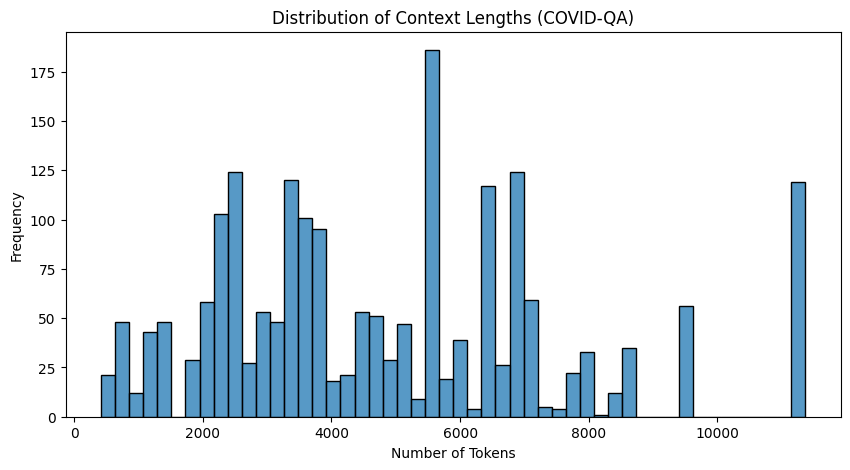

In [6]:
# Distribution of Context Lengths

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))
sns.histplot(df4["context_length"], bins=50)
plt.title("Distribution of Context Lengths (COVID-QA)")
plt.xlabel("Number of Tokens")
plt.ylabel("Frequency")
plt.show()

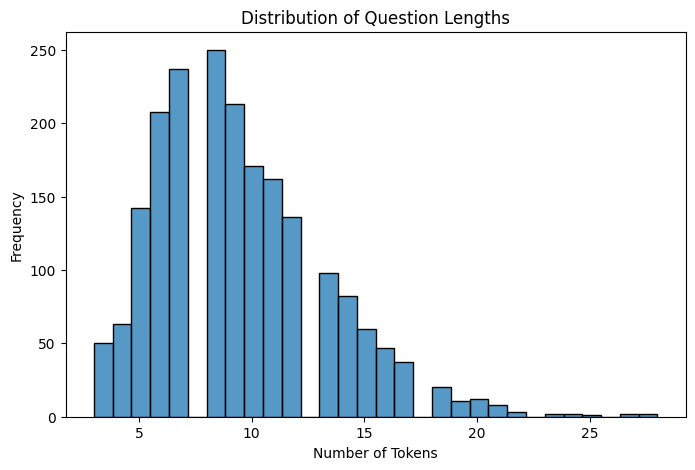

In [7]:
# Question Length Distribution

plt.figure(figsize=(8,5))
sns.histplot(df4["question_length"], bins=30)
plt.title("Distribution of Question Lengths")
plt.xlabel("Number of Tokens")
plt.ylabel("Frequency")
plt.show()

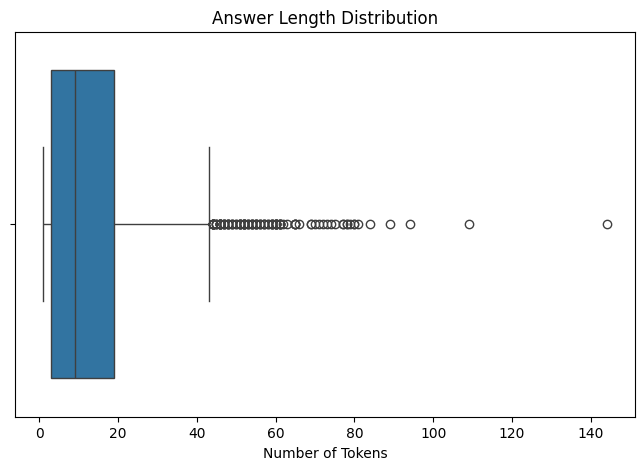

In [8]:
# Answer Length Distribution

plt.figure(figsize=(8,5))
sns.boxplot(x=df4["answer_length"])
plt.title("Answer Length Distribution")
plt.xlabel("Number of Tokens")
plt.show()

# Embedding Preparation

In [9]:
df4_validanswer = df4[df4["is_impossible"] == False]

In [10]:
df4_validanswer.tail()

,document_id,context,question,answer,is_impossible,question_length,answer_length,context_length
2014,1713,"Ebola Virus Maintenance: If Not (Only) Bats, W...",What is the structure of the Ebolavirus?,single-strand RNA filoviruses,False,7,3,4813
2015,1713,"Ebola Virus Maintenance: If Not (Only) Bats, W...",When was the West African Ebolavirus outbreak?,2013-2016,False,7,1,4813
2016,1713,"Ebola Virus Maintenance: If Not (Only) Bats, W...",What animals are considered to be maintenance ...,African bats,False,11,2,4813
2017,1713,"Ebola Virus Maintenance: If Not (Only) Bats, W...",What do circles indicate in Figure 1?,a maintenance function play by the host(s),False,7,7,4813
2018,1713,"Ebola Virus Maintenance: If Not (Only) Bats, W...",What do arrows indicate in Figure 1?,infectious transmission pathways between hosts,False,7,5,4813


In [11]:
df4_validanswer["question"].iloc[1]

'What plays the crucial role in the Mother to Child Transmission of HIV-1 and what increases the risk'

In [12]:
df4_validanswer["answer"].iloc[1]

'DC-SIGNR plays a crucial role in MTCT of HIV-1 and that impaired placental DC-SIGNR expression increases risk of transmission.'

In [13]:
df4_validanswer["question"].iloc[0]

'What is the main cause of HIV-1 infection in children?'

In [14]:
df4_validanswer["answer"].iloc[0]

'Mother-to-child transmission (MTCT) is the main cause of HIV-1 infection in children worldwide. '

# Embedding Preparation

In [22]:
EMBEDDING_MODEL = "text-embedding-3-large"
EMBEDDING_DIM = 3072

In [15]:
!pip install langchain
!pip install openai
!pip install tiktoken

In [16]:
!pip install -U langchain-text-splitters

In [17]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

In [18]:
splitter = RecursiveCharacterTextSplitter(
    chunk_size=300,
    chunk_overlap=50
)

In [19]:
def chunk_faq(row):
    chunks = splitter.split_text(row["answer"])
    documents = []

    for i, chunk in enumerate(chunks):
        text = f"""Question: {row['question']}

Answer (Part {i+1}): {chunk}"""
        documents.append((text, i))

    return documents

In [20]:
from langchain_core.documents import Document

In [21]:
documents = []

for _, row in df4_validanswer.iterrows():
    chunks = chunk_faq(row)
    for text, chunk_id in chunks:
        metadata = {
            "document_id": row["document_id"],
            "dataset": "covid-qa-master"
        }

        documents.append(
            Document(
                page_content=text,
                metadata=metadata
            )
        )

In [23]:
import tiktoken

encoding = tiktoken.encoding_for_model(EMBEDDING_MODEL)

def count_tokens(text: str) -> int:
    """
    Count tokens for a given text using tiktoken.
    """
    return len(encoding.encode(text))


def add_token_metadata(documents):
    """
    Adds token count to each Document's metadata.
    """
    for doc in documents:
        doc.metadata["embedding_tokens"] = count_tokens(doc.page_content)
    return documents

In [24]:
documents = add_token_metadata(documents)

# Data Indexing (Embeddings)

### FAISS: Facebook AI Similarity Search

[Link](https://docs.langchain.com/oss/python/integrations/vectorstores/faiss)

In [26]:
from openai import OpenAI
from google.colab import userdata

In [27]:
api_key = userdata.get('OPENAI_API_KEY')

In [28]:
os.environ["OPENAI_API_KEY"] = api_key

In [29]:
client = OpenAI()

In [30]:
!pip install langchain_openai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.8/84.8 kB 2.5 MB/s eta 0:00:00


In [31]:
!pip install -qU langchain-community faiss-cpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.7/64.7 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 1.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.32.5 which is incompatible.


In [32]:
import faiss
from langchain_community.docstore.in_memory import InMemoryDocstore
from langchain_openai import OpenAIEmbeddings
from langchain_community.vectorstores import FAISS

In [33]:
embeddings = OpenAIEmbeddings(model=EMBEDDING_MODEL)

In [34]:
index = faiss.IndexFlatL2(EMBEDDING_DIM)

vector_store = FAISS(
    embedding_function=embeddings,
    index=index,
    docstore=InMemoryDocstore(),
    index_to_docstore_id={},
)

#### Add items to vector store

In [35]:
from uuid import uuid4

In [36]:
uuids = [str(uuid4()) for _ in range(len(documents))]

vector_store.add_documents(documents=documents, ids=uuids)

['f98791d0-d3c1-46a1-9721-020dddc377f1',
 'ae3a36f1-dbd4-4161-bb58-37fcc86c2ba0',
 'caabaa35-c22e-4f13-bfd5-17449076f81e',
 'a9bf994e-6df0-4c4c-96c0-e41625c6c73b',
 '4f10d63f-ecc0-419a-a17f-17d01e07588f',
 'dac51c3c-ec62-4525-ab60-1a0155645c44',
 '7412aee7-4e31-4870-930d-4e467148e173',
 '7d636c48-c238-4eac-a62c-d4eb138218da',
 'c21c55eb-4e4f-44ee-a3a5-4e5a7625e0b2',
 '9ba238f1-9529-4857-9489-d587dcad0814',
 '64ca1d67-2858-484d-98d3-481d07f06b02',
 '0867cfe0-b93f-49c1-9c25-340e64268299',
 'fccf1cd8-ba5e-4774-99af-207e76213365',
 'a45dca93-1167-41e8-86c2-6a03c972ce29',
 'c8026301-a456-46a2-b708-b762405593cf',
 '8cfbe66b-1b8b-493d-acc0-f0e7022acef6',
 '658cea7d-d066-4ac0-b5f3-8bcfaa85d98e',
 'de304a35-105e-4088-b5c3-be3d3e717a2d',
 '9155c0d8-660f-42a8-88f9-95739719fc52',
 '7c4a616e-59ef-4054-acac-d80574a45c0a',
 '3b0f32ef-be85-4872-b375-68d7a51392f9',
 'a1e10099-fe1f-4b06-bd11-963854efbe28',
 '2c212675-e0d3-4024-a4d1-69ffd08b9496',
 'ca4133f4-47db-480a-92a9-2cdcfd9e29fd',
 '8e0fbd67-d7ce-

#### Saving Vector Store

In [37]:
documents[0]

Document(metadata={'document_id': 630, 'dataset': 'covid-qa-master', 'embedding_tokens': 42}, page_content='Question: What is the main cause of HIV-1 infection in children?\n\nAnswer (Part 1): Mother-to-child transmission (MTCT) is the main cause of HIV-1 infection in children worldwide.')

In [38]:
vector_store_path = os.path.join("/content/drive/MyDrive/MS-LJMU/Vector-Store", "Store-4-3072-COVID-QA-MASTER")

In [39]:
vector_store.save_local(vector_store_path)